## Practice with GPT2 Implementation

This is based on [picoGPT](https://github.com/jaymody/picoGPT/blob/29e78cc52b58ed2c1c483ffea2eb46ff6bdec785/gpt2_pico.py#L3-L58)

We'll use some utility functions provided there to download the model and tokenizer.

In [ ]:
# clone the repo to a temporary directory
# repo: https://github.com/jaymody/picoGPT/commit/817292baea75f194fb0bb8ba2aa5f947af4e45ee
from pathlib import Path
import tempfile
import subprocess

repo_dir = Path(tempfile.mkdtemp())
subprocess.run(
    ["git", "clone", "https://github.com/jaymody/picoGPT/", str(repo_dir), "--revision", "817292baea75f194fb0bb8ba2aa5f947af4e45ee"],
    check=True,
)

Cloning into '/var/folders/8m/_kxvbfmn3kzgz67pbt731pcw0000gp/T/tmpkmbixbl7'...
Note: switching to '817292baea75f194fb0bb8ba2aa5f947af4e45ee'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false



CompletedProcess(args=['git', 'clone', 'https://github.com/jaymody/picoGPT/', '/var/folders/8m/_kxvbfmn3kzgz67pbt731pcw0000gp/T/tmpkmbixbl7', '--revision', '817292baea75f194fb0bb8ba2aa5f947af4e45ee'], returncode=0)

In [88]:
repo_dir

PosixPath('/var/folders/8m/_kxvbfmn3kzgz67pbt731pcw0000gp/T/tmpkmbixbl7')

In [5]:
!ls {repo_dir}

LICENSE           encoder.py        gpt2_pico.py      utils.py
README.md         gpt2.py           requirements.txt


In [6]:
%cd {repo_dir}

/private/var/folders/8m/_kxvbfmn3kzgz67pbt731pcw0000gp/T/tmpkmbixbl7


/Users/ka37/code/github.com/Calvin-Data-Science/cs375-376/.venv/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [63]:
# import modules
import numpy as np
import importlib
import gpt2 # we will overwrite functions here for our implementation
import gpt2_pico
import utils
importlib.reload(gpt2)
importlib.reload(gpt2_pico)

<module 'gpt2_pico' from '/private/var/folders/8m/_kxvbfmn3kzgz67pbt731pcw0000gp/T/tmpkmbixbl7/gpt2_pico.py'>

In [15]:
prompt = "Have a very nice"

In [ ]:
gpt2.main(prompt, n_tokens_to_generate=10)

generating: 100%|██████████| 40/40 [00:09<00:00,  4.39it/s]


" day, and I'll be back soon.\n\nI'm sorry, but I'm not sure if I'm going to be able to get back to work. I'm not sure if I'm"

In [ ]:
gpt2.main(prompt, n_tokens_to_generate=10)

generating: 100%|██████████| 10/10 [00:01<00:00,  5.56it/s]


" day, and I'll be back soon.\n"

> Question: Why do these functions always give the same output? Look at the `generate` function in https://github.com/jaymody/picoGPT/blob/main/gpt2.py to answer.

*your answer here*

`np.argmax`

# Doing it ourselves

First we set up: we load the model parameters and the tokenizer.

In [30]:
model_size: str = "124M"
models_dir: str = "models"

# load encoder, hparams, and params from the released open-ai gpt-2 files
encoder, hparams, params = utils.load_encoder_hparams_and_params(model_size, models_dir)

# hack: put n_head in params
#params["n_head"] = hparams["n_head"]

# encode the input string using the BPE tokenizer
input_ids = encoder.encode(prompt)

`params` is one big dictionary that contains all the model parameters. Let's have a quick look:

In [37]:
params.keys()

dict_keys(['blocks', 'ln_f', 'wpe', 'wte'])

For example, `wte` is the *weights* for the **t**oken **e**mbeddings. Do you recognize this shape?

In [38]:
params['wte'].shape

(50257, 768)

The parameters for each transformer layer are stored in the `blocks` key. For example, here are the query, key, and value projection matrices for the first layer (they're jammed together into one giant matrix with 768 * 3 columns). The first 768 columns are the query projection matrix, the next 768 columns are the key projection matrix, and the last 768 columns are the value projection matrix. The shape of this matrix is (768, 768 * 3).

In [43]:
params['blocks'][0]['attn']['c_attn']['w'].shape

(768, 2304)

Since there's a lot of parameters, let's grab out examples of how these functions are called. Skip over the details of how this code works.

In [74]:
dir(gpt2_pico)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'attention',
 'ffn',
 'gelu',
 'generate',
 'gpt2',
 'layer_norm',
 'linear',
 'main',
 'mha',
 'np',
 'softmax',
 'transformer_block']

In [83]:
from collections import namedtuple
Args = namedtuple('Args', 'args kwargs')

def grab_example_wrapper(module, function_name):
    """Temporarily replace a function in a module with a wrapper that captures some example inputs and output."""

    original_function = getattr(module, function_name)
    if hasattr(original_function, 'is_wrapper'):
        raise ValueError(f"{function_name} is already wrapped.")

    capture_dict = {}
    def wrapper(*args, **kwargs):
        capture_dict['inputs'] = Args(args=args, kwargs=kwargs)
        capture_dict['output'] = original_function(*args, **kwargs)
        setattr(module, function_name, original_function)
        return capture_dict['output']
    wrapper.is_wrapper = True

    setattr(module, function_name, wrapper)
    return capture_dict


functions_to_capture = ['gelu', 'softmax', 'linear', 'mha', 'layer_norm', 'attention']
captured_examples = {func_name: grab_example_wrapper(gpt2_pico, func_name) for func_name in functions_to_capture}
# run the model to capture example inputs and output
gpt2_pico.main(prompt, n_tokens_to_generate=10)

generating: 100%|██████████| 10/10 [00:01<00:00,  5.33it/s]


" day, and I'll be back soon.\n"

In [84]:
example_gelu_input = captured_examples['gelu']['inputs'].args[0]
example_gelu_input.shape

(4, 3072)

In [85]:
captured_examples['gelu']['output']

array([[-0.11484193, -0.08937085, -0.16367051, ..., -0.00160387,
        -0.08544072,  1.13865125],
       [ 0.07716836, -0.05239069, -0.15784323, ..., -0.14965268,
        -0.1019014 ,  0.1478406 ],
       [ 0.05035945, -0.13671486, -0.13438418, ..., -0.09410181,
        -0.13952271, -0.04364456],
       [ 0.18930948, -0.08418035, -0.09745774, ..., -0.0595882 ,
        -0.15441513,  0.01458391]])

In [81]:
gpt2.gelu(example_gelu_input).shape

(4, 3072)

In [87]:
np.allclose(
    captured_examples['gelu']['output'],
    gpt2.gelu(example_gelu_input))

True

## Our own `generate` loop

Here is the reference implementation of the `generate` function from the picoGPT repo:

```python
def generate(inputs, params, n_head, n_tokens_to_generate):
    from tqdm import tqdm

    for _ in tqdm(range(n_tokens_to_generate), "generating"):  # auto-regressive decode loop
        logits = gpt2(inputs, **params, n_head=n_head)  # model forward pass
        next_id = np.argmax(logits[-1])  # greedy sampling
        inputs.append(int(next_id))  # append prediction to input

    return inputs[len(inputs) - n_tokens_to_generate :]  # only return generated ids
```

## Step 1: generate the first token yourself.

Above, we computed the token ids for the prompt:

In [18]:
input_ids

[11980, 257, 845, 3621]

In [31]:
# your code here
logits = gpt2.gpt2(input_ids, **params, n_head=hparams['n_head'])
last_token_logits = logits[-1]
next_token = np.argmax(last_token_logits, axis=-1)
# decode the predicted token id to a string
encoder.decode([next_token])

' day'

## Step 2: Rewrite the `generate` function yourself.

Don't worry about `tqdm` progress reporting.

For extra bonus, give it a `temperature` parameter; if `temperature` is 0 then use argmax, otherwise sample.

In [32]:
def my_generate(inputs, params, n_head, n_tokens_to_generate):
    # Implement the generation loop here <<SOLN
    for i in range(n_tokens_to_generate):
        logits = gpt2.gpt2(inputs, **params, n_head=n_head)  # model forward pass
        next_id = np.argmax(logits[-1])  # greedy sampling
        inputs.append(int(next_id))  # append prediction to input

    return inputs[len(inputs) - n_tokens_to_generate :]  # only return generated ids
    ## SOLN

# stick it back in the gpt2 module
gpt2.generate = my_generate
gpt2.main(prompt, n_tokens_to_generate=10)

" day, and I'll be back soon.\n"

## Implement GeLU

The reference implementation is:

```python
def gelu(x):
    return 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))
```

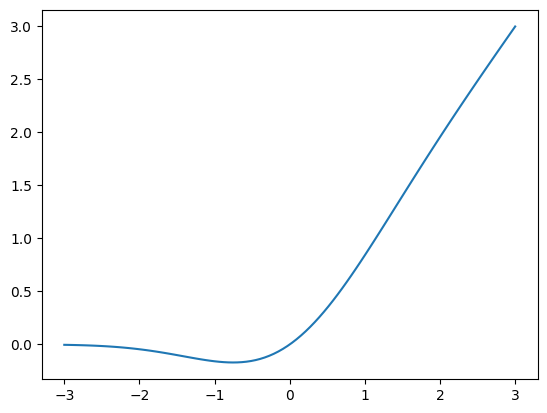

In [57]:
import matplotlib.pyplot as plt

def gelu(x):
    return 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))

x = np.linspace(-3, 3, 100)
y = gelu(x)
plt.plot(x, y);

In [58]:
# let's try replacing it with plain ReLU and see if it breaks!
def relu(x):
    return np.maximum(0, x)

# stick it back in the gpt2 module
gpt2.gelu = relu
gpt2.main(prompt, n_tokens_to_generate=10)

', the, the, and, the, the'

In [60]:
# now put it back to GeLU
def gelu(x):
    return 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))
gpt2.gelu = gelu
gpt2.main(prompt, n_tokens_to_generate=10)

" day, and I'll be back soon.\n"

## Implement softmax

## Implement the feed-forward network component

Here's the reference implementation:

```python
def ffn(x, c_fc, c_proj):  # [n_seq, n_embd] -> [n_seq, n_embd]
    # project up
    a = gelu(linear(x, **c_fc))  # [n_seq, n_embd] -> [n_seq, 4*n_embd]

    # project back down
    x = linear(a, **c_proj)  # [n_seq, 4*n_embd] -> [n_seq, n_embd]

    return x
```

Let's do it ourselves.

In [50]:
# grab out an example of an MLP layer's weights.
# don't worry about what this code is doing :)
mlp_params = params['blocks'][0]['mlp']
c_fc = mlp_params['c_fc']
c_proj = mlp_params['c_proj']
c_fc['w'].shape, c_proj['w'].shape

((768, 3072), (3072, 768))

First, do it by hand on a simple example.

In [55]:
example_x = np.random.randn(4, hparams['n_embd'])
hidden_states = gpt2.gelu(gpt2.linear(example_x, c_fc['w'], c_fc['b']))
np.allclose(
    gpt2.linear(hidden_states, c_proj['w'], c_proj['b']),
    gpt2.ffn(example_x, **mlp_params)
)


True

In [ ]:

linear_output = grab_example_wrapper(gpt2, 'linear')
ffn_output = grab_example_wrapper(gpt2, 'ffn')

# run the model to get the inputs and outputs
gpt2.main(prompt, n_tokens_to_generate=10)
# grab the inputs and outputs
(example_linear_x,), example_linear_params = linear_output['inputs']
linear_outputs = linear_output['outputs']
ffn_inputs = ffn_output['inputs']
ffn_outputs = ffn_output['outputs']

generating: 100%|██████████| 10/10 [00:01<00:00,  5.36it/s]


In [72]:
linear_output['outputs'].shape

(4, 2304)

In [73]:
gpt2.linear(example_linear_x, **example_linear_params).shape

(4, 2304)